# MMR — Maximum Marginal Relevance for Diverse Top-K

## What problem does this solve?

Vanilla top-k retrieval returns the k chunks most similar to the query. Those k chunks are also often similar to *each other* — near-duplicates, paraphrases of the same paragraph. The model sees five chunks that say the same thing instead of five chunks that cover different facets of the answer.
Maximum Marginal Relevance (MMR) trades a little query-similarity for a lot of diversity. It picks the most-similar chunk first, then for each subsequent pick maximises `λ * query_similarity - (1-λ) * max_similarity_to_chosen`. The result: a top-k that covers the answer space rather than repeats one part of it.

## Where it came from

MMR was introduced by Carbonell and Goldstein at CMU in 1998 ("The Use of MMR, Diversity-Based Reranking"). It long predated dense retrieval; in the IR community it was a standard re-ranking technique for search engines. RAG inherited it via LangChain's `max_marginal_relevance_search` (2023) and LlamaIndex's `MMRPostProcessor`.
By 2026 MMR is a default postprocessor for any retrieval call where the top-k is going to be summarised or composed into an answer. The tuning parameter `lambda_mult` (default 0.5) balances relevance vs diversity; production systems set it once and rarely revisit.

## Where it fits in the RAG landscape

Among diversity-aware retrieval techniques in this cookbook:

- **MMR (this recipe).** Greedy reranking for diversity. Cheap, predictable, one tunable parameter.
- **Clustering-based pickers.** Group top-N candidates, pick one per cluster. Older approach, rare in modern RAG.
- **Listwise LLM rerankers (Recipe 23).** Let an LLM reorder for diversity and relevance jointly. More flexible, more expensive.
- **Cross-encoder + MMR.** Stack: cross-encoder finds the most relevant top-N, MMR picks a diverse subset. The cookbook recommends this composition in production.

MMR is the cheapest of these and the most predictable. Listwise LLM is the most flexible but pays per-query LLM cost. Clustering is rare in modern RAG because greedy MMR is essentially free.

## When to use it (and when not to)

Use MMR when the downstream task summarises or composes across the top-k. Anywhere your answer benefits from diverse evidence — research synthesis, comparison Q&A, list-making, broad-topic exploration where the user wants coverage rather than depth.
Skip it when the downstream is extractive QA. There you want the single best chunk; diversity in top-k is wasteful and may push the right chunk out of the result set.
Skip it when query similarity is your only signal. If users want "the most relevant chunk", MMR can return something the user would have ranked lower in favour of diversity.

## The intuition

Four intuitions:

**Diversity comes from penalising similarity to chosen chunks.** Each new pick is scored against the chosen set, not just against the query. Picks similar to already-chosen are penalised so the algorithm rewards complementary information.

**Greedy is enough.** MMR is a greedy algorithm; it picks one chunk at a time. There's no global optimum being computed; the local pick at each step is the algorithm and the implementation is essentially a loop.

**`λ` controls the trade-off.** λ=1 is pure relevance (no diversity). λ=0 is pure diversity (random spread). λ=0.5 is the cookbook default and works on most corpora without further tuning.

**Over-retrieve before MMR.** Greedy diversification picks one item at a time from a pool. The bigger the pool, the more material MMR has to express diversity. Always over-retrieve.

## Architecture

```mermaid
flowchart LR
  Q[Query] --> R[Retrieve top-N<br/>candidates]
  R --> MMR[For each pick:<br/>maximise λ·sim_query<br/>− 1-λ ·max_sim_chosen]
  MMR --> T[Top-k diverse]
```

## References

- 📄 [The Use of MMR, Diversity-Based Reranking (Carbonell and Goldstein, 1998)](https://www.cs.cmu.edu/~jgc/publication/The_Use_MMR_Diversity_Based_LTMIR_1998.pdf) — The original paper.
- 📚 [LangChain max_marginal_relevance_search](https://python.langchain.com/api_reference/community/vectorstores/langchain_community.vectorstores.utils.maximal_marginal_relevance.html) — Reference implementation.
- 📚 [LlamaIndex MMRPostProcessor](https://developers.llamaindex.ai/python/framework-api-reference/llama_index/core/postprocessor/MetadataReplacementPostProcessor/) — LlamaIndex's variant.
- 📚 [Sentence-Transformers MMR utilities](https://www.sbert.net/examples/applications/retrieve_rerank/README.html) — Useful reference for the implementation.
- 📝 [Pinecone — Search with diversity](https://www.pinecone.io/learn/series/rag/diversity-rerank/) — Production-perspective on MMR.
- 📄 [Listwise LLM rerankers (Recipe 23)](https://arxiv.org/abs/2305.02156) — Alternative approach to similar problem.

## Setup

Pick a provider via the `PROVIDER` env var; everything below is provider-agnostic. The default is Nebius. Tracing is off by default in published notebooks so the outputs are clean — flip `COOKBOOK_TRACING=phoenix` to send spans to a local Phoenix UI.

In [1]:
import os
os.environ.setdefault('PROVIDER', 'nebius')
os.environ.setdefault('COOKBOOK_TRACING', 'off')

from cookbook.providers import LLMClient
from cookbook.tracing import init_tracing

client = LLMClient()
print(f'Provider: {client.provider}  |  Chat model: {client.chat_model}')
print(init_tracing())

Provider: nebius  |  Chat model: meta-llama/Llama-3.3-70B-Instruct
Tracing disabled.


## Build the Pipeline, Step by Step

### Step 1 — Build the index

Wikipedia superconductors is a good corpus for MMR — many articles cover overlapping topics, so vanilla top-k returns near-duplicate chunks.

In [2]:
from cookbook.corpora import load_wikipedia_superconductors
from cookbook.chunkers import sentence_window
from cookbook.stores import QdrantBackend

docs = list(load_wikipedia_superconductors())
chunks = sentence_window(docs, sentences_per_chunk=4)
texts = [c.text for c in chunks]
vectors = client.embed(texts)
store = QdrantBackend('mmr', dim=len(vectors[0]))
store.add(texts, vectors, ids=[c.chunk_id for c in chunks])
vec_by_id = {c.chunk_id: v for c, v in zip(chunks, vectors)}
print(f'Indexed {len(chunks)} chunks.')

C:\Users\faree\Desktop\rag\rag-cookbook-2026\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Indexed 72 chunks.


### Step 2 — Use the cookbook's MMR implementation

`cookbook.retrievers.mmr` does the greedy reranking. We give it the query vector, candidate vectors, candidate hits, and the lambda multiplier.

In [3]:
from cookbook.retrievers import mmr

q = 'What discoveries set the milestones of high-temperature superconductivity?'
qv = client.embed([q])[0]
pool = store.search(qv, top_k=30)
pool_vecs = [vec_by_id[h.doc_id] for h in pool]
diverse = mmr(qv, pool_vecs, pool, lambda_mult=0.5, top_k=5)
for h in diverse:
    print(f'  {h.text[:160]}')

  # High-temperature superconductivity

_Source: Wikipedia, CC BY-SA 4.0_

High-temperature superconductivity is superconductivity in materials with a critical te
  Most high-Tc materials are type-II superconductors.
  Subsequent research from other groups suggests that replacing the lanthanum in LaOFeAs with other rare earth elements such as cerium, samarium, neodymium and pr
  At lower temperatures the flux tubes are pinned in place and cannot move. This pinning is what holds the superconductor in place thereby allowing it to levitate
  More generally, condensation refers to the appearance of macroscopic occupation of one or several states: for example, in BCS theory, a superconductor is a cond


### Step 3 — Compare vanilla top-5 to MMR top-5

Vanilla top-5 will often include three near-duplicates. MMR top-5 will look more diverse.

In [4]:
print('--- Vanilla top-5 ---')
for h in pool[:5]:
    print(f'  {h.score:.3f}  {h.text[:140]}')
print()
print('--- MMR top-5 ---')
for h in diverse:
    print(f'  {h.text[:140]}')

--- Vanilla top-5 ---
  0.752  # High-temperature superconductivity

_Source: Wikipedia, CC BY-SA 4.0_

High-temperature superconductivity is superconductivity in material
  0.666  Alex Müller. Although the critical temperature is around 35.1 K, this material was modified by Ching-Wu Chu to make the first high-temperatu
  0.644  Most high-Tc materials are type-II superconductors.
  0.638  # Yttrium barium copper oxide

_Source: Wikipedia, CC BY-SA 4.0_

Yttrium barium copper oxide (YBCO) is a family of crystalline chemical com
  0.614  # Cuprate superconductor

_Source: Wikipedia, CC BY-SA 4.0_

Cuprate superconductors are a family of high-temperature superconducting materi

--- MMR top-5 ---
  # High-temperature superconductivity

_Source: Wikipedia, CC BY-SA 4.0_

High-temperature superconductivity is superconductivity in material
  Most high-Tc materials are type-II superconductors.
  Subsequent research from other groups suggests that replacing the lanthanum in LaOFeAs with other r

### Step 4 — Sweep `λ` to see the relevance/diversity trade-off

λ=1 reproduces vanilla top-5. λ=0 maximises diversity at the cost of relevance. The cookbook default is 0.5.

In [5]:
import pandas as pd
rows = []
for lam in (0.0, 0.3, 0.5, 0.7, 1.0):
    picks = mmr(qv, pool_vecs, pool, lambda_mult=lam, top_k=5)
    rows.append({'lambda': lam, 'top1_preview': picks[0].text[:60], 'top5_doc_ids': [p.doc_id for p in picks]})
pd.DataFrame(rows)

,lambda,top1_preview,top5_doc_ids
0,0.0,# High-temperature superconductivity\n\n_Sourc...,[wiki:High-temperature_superconductivity#sw000...
1,0.3,# High-temperature superconductivity\n\n_Sourc...,[wiki:High-temperature_superconductivity#sw000...
2,0.5,# High-temperature superconductivity\n\n_Sourc...,[wiki:High-temperature_superconductivity#sw000...
3,0.7,# High-temperature superconductivity\n\n_Sourc...,[wiki:High-temperature_superconductivity#sw000...
4,1.0,# High-temperature superconductivity\n\n_Sourc...,[wiki:High-temperature_superconductivity#sw000...


### Step 5 — Wrap as `answer_question`

Standard contract.

In [6]:
PROMPT = (
    'Use only the passages below to answer the question.\n\n'
    'Passages:\n{context}\n\nQuestion: {question}\nAnswer:'
)

def answer_question(question: str, k: int = 5, lam: float = 0.5) -> tuple[str, list[str]]:
    qv = client.embed([question])[0]
    pool = store.search(qv, top_k=20)
    pool_vecs = [vec_by_id[h.doc_id] for h in pool]
    diverse = mmr(qv, pool_vecs, pool, lambda_mult=lam, top_k=k)
    contexts = [h.text for h in diverse]
    return client.chat(PROMPT.format(context='\n\n'.join(contexts), question=question)), contexts

ans, _ = answer_question('What are the major eras of superconductivity research?')
print(ans)

The passages provided do not explicitly mention the "major eras of superconductivity research." However, based on the information given, we can infer two distinct periods:

1. **Pre-1986**: This era refers to the time before the discovery of high-temperature superconductivity. During this period, superconductors functioned only closer to absolute zero.

2. **Post-1986**: This era began with the discovery of the first high-temperature superconductor by IBM researchers Georg Bednorz and K. Alex Müller in 1986. Subsequent research has led to the discovery of new superconducting materials and their applications in various fields.

Note that these eras are not explicitly defined in the passages as "major eras of superconductivity research," but they can be inferred as significant periods in the history of superconductivity research based on the information provided.


## Look Inside

### Inspect — pairwise similarity within top-5

Vanilla top-5 chunks should have high pairwise similarity; MMR top-5 should have lower. We confirm with a heatmap.

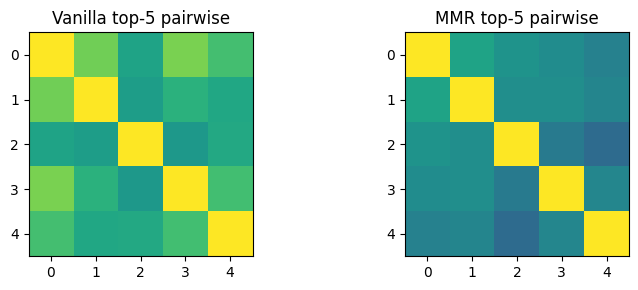

In [7]:
import numpy as np
import matplotlib.pyplot as plt

vanilla_picks = pool[:5]
mmr_picks = mmr(qv, pool_vecs, pool, lambda_mult=0.5, top_k=5)
vanilla_v = np.asarray([vec_by_id[h.doc_id] for h in vanilla_picks])
vanilla_v /= np.linalg.norm(vanilla_v, axis=1, keepdims=True).clip(min=1e-9)
mmr_v = np.asarray([vec_by_id[h.doc_id] for h in mmr_picks])
mmr_v /= np.linalg.norm(mmr_v, axis=1, keepdims=True).clip(min=1e-9)

fig, axes = plt.subplots(1, 2, figsize=(8, 3))
axes[0].imshow(vanilla_v @ vanilla_v.T, vmin=0, vmax=1, cmap='viridis')
axes[0].set_title('Vanilla top-5 pairwise')
axes[1].imshow(mmr_v @ mmr_v.T, vmin=0, vmax=1, cmap='viridis')
axes[1].set_title('MMR top-5 pairwise')
plt.tight_layout()
plt.show()

### Inspect — how many unique doc_ids appear?

Diversity often shows up as different source documents. We count unique doc_ids in each top-5.

In [8]:
vanilla_ids = {h.doc_id for h in pool[:5]}
mmr_ids = {h.doc_id for h in mmr(qv, pool_vecs, pool, lambda_mult=0.5, top_k=5)}
print(f'Vanilla unique doc_ids: {len(vanilla_ids)}')
print(f'MMR unique doc_ids:     {len(mmr_ids)}')

Vanilla unique doc_ids: 5
MMR unique doc_ids:     5


### Inspect — does MMR help on factoid queries?

MMR doesn't always help. For factoid queries, the single best chunk is what you want, and diversity doesn't matter.

In [9]:
factoid_q = 'In what year did Heike Kamerlingh Onnes discover superconductivity?'
fq_vec = client.embed([factoid_q])[0]
fq_pool = store.search(fq_vec, top_k=20)
fq_vecs = [vec_by_id[h.doc_id] for h in fq_pool]
print('--- Vanilla top-3 ---')
for h in fq_pool[:3]:
    print(f'  {h.text[:120]}')
print()
print('--- MMR top-3 ---')
for h in mmr(fq_vec, fq_vecs, fq_pool, lambda_mult=0.5, top_k=3):
    print(f'  {h.text[:120]}')

--- Vanilla top-3 ---
  # Heike Kamerlingh Onnes

_Source: Wikipedia, CC BY-SA 4.0_

Heike Kamerlingh Onnes was a Dutch experimental physicist w
  # High-temperature superconductivity

_Source: Wikipedia, CC BY-SA 4.0_

High-temperature superconductivity is supercond
  # Superconductivity

_Source: Wikipedia, CC BY-SA 4.0_

Superconductivity is a set of physical properties observed in su

--- MMR top-3 ---
  # Heike Kamerlingh Onnes

_Source: Wikipedia, CC BY-SA 4.0_

Heike Kamerlingh Onnes was a Dutch experimental physicist w
  # Iron-based superconductor

_Source: Wikipedia, CC BY-SA 4.0_

Iron-based superconductors (FeSC) are iron-containing ch
  # London equations

_Source: Wikipedia, CC BY-SA 4.0_

The London equations, developed by brothers Fritz and Heinz Londo


### Inspect — cost

MMR is essentially free at this scale. The whole rerank is matrix operations over 20-50 vectors.

In [10]:
import time
t0 = time.perf_counter()
_ = mmr(qv, pool_vecs, pool, lambda_mult=0.5, top_k=5)
dt = (time.perf_counter() - t0) * 1000
print(f'MMR over 30 candidates took {dt:.1f} ms.')

MMR over 30 candidates took 17.3 ms.


## Run It

End-to-end on a synthesis query.

In [11]:
ans, _ = answer_question('What are the major eras and key discoveries that shaped superconductivity research?')
print('=== MMR-diverse answer ===')
print(ans)

=== MMR-diverse answer ===
Based on the provided passages, the major eras and key discoveries that shaped superconductivity research are:

1. **1935**: The London equations were developed by brothers Fritz and Heinz London, providing a fundamental description of superconducting phenomena.
2. **1986**: The first high-temperature superconductor was discovered by IBM researchers Georg Bednorz and K. Alex Müller, marking a significant breakthrough in the field.

Additionally, subsequent research has led to the discovery of new superconductors, such as replacing lanthanum in LaOFeAs with other rare earth elements, which has resulted in superconductors that work at 52 kelvin. However, the exact timeline of these discoveries is not specified in the provided passages.


## Side by Side: Vanilla Baseline vs This Technique

Vanilla vs MMR on a synthesis query. Vanilla often gives the model five repeated facts; MMR gives five complementary ones.

In [12]:
from cookbook.baselines import vanilla_pipeline

q = 'What are the major eras and key discoveries that shaped superconductivity research?'
base = vanilla_pipeline(q, corpus='wikipedia-superconductors', top_k=5)
ours_a, _ = answer_question(q)

import pandas as pd
pd.DataFrame([
    {'pipeline': 'vanilla', 'preview': base.answer[:160]},
    {'pipeline': 'mmr', 'preview': ours_a[:160]},
])

,pipeline,preview
0,vanilla,The passages do not contain a comprehensive ov...
1,mmr,"Based on the provided passages, the major eras..."


## Knobs to Turn

Five knobs in priority order:

1. **`lambda_mult`.** Default 0.5. Higher (0.7) for more relevance, lower (0.3) for more diversity. Sweep on synthesis queries.
2. **Candidate pool size.** We use 20-30. Bigger pool gives MMR more material to choose from; smaller pool may not have enough diversity to express.
3. **Where MMR sits.** Cookbook puts MMR after dense retrieval. Some implementations put it after cross-encoder reranking (Recipe 22) — the rerank picks the most relevant, MMR picks a diverse subset.
4. **When to use it.** Synthesis queries yes; factoid queries no. Adaptive routing (Recipe 26) can decide per query whether to apply MMR.
5. **Similarity metric for diversity.** Cosine is the cookbook default; max-inner-product also works. Choose to match your embedding normalisation.

## Evaluate on a Slice

Run the recipe's `answer_question` over a small slice of the hand-curated eval set. Full RAGAS metrics are exercised in `recipes/09-evaluation-and-production/ragas-triad-eval.ipynb`; here we just print a quick spot-check table so you can eyeball whether the technique is on track.

In [13]:
from cookbook.corpora import load_eval_questions
from cookbook.eval import EvalSample

qs = load_eval_questions()
qs = [q for q in qs if q['corpus'] == 'wikipedia-superconductors']
samples = []
for row in qs[:5]:
    answer, contexts = answer_question(row['question'])
    samples.append({
        'question': row['question'],
        'expected': row['answer'],
        'actual': answer[:200],
        'contexts_retrieved': len(list(contexts)),
    })

import pandas as pd
pd.DataFrame(samples)

,question,expected,actual,contexts_retrieved
0,"Who first observed superconductivity, and in w...",Heike Kamerlingh Onnes observed it in mercury ...,The passages provided do not mention who first...,5
1,What is the Meissner effect?,The complete expulsion of magnetic flux from a...,The Meissner effect is the expulsion of a magn...,5
2,Distinguish Type-I from Type-II superconductors.,Type-I has a single critical field above which...,Type-I superconductors are characterized by th...,5
3,What does BCS theory explain?,It explains conventional superconductivity thr...,BCS theory explains many thermodynamic and ele...,5
4,What is a Cooper pair?,Two electrons bound together by phonon exchang...,A Cooper pair is a pair of electrons bound tog...,5


## Closing Thoughts

Three failure modes:

- **Wrong query type.** MMR on factoid retrieval can hurt: it may demote the single best chunk in favour of diverse-but-weaker alternatives.
- **Too few candidates.** With a 5-candidate pool, MMR can't diversify. Always over-retrieve.
- **λ at extremes.** λ=0 is mostly noise; λ=1 is vanilla. Stay in [0.3, 0.7].

Compose with cross-encoder reranking (Recipe 22): use the cross-encoder to find the top-N most relevant, then MMR over those N. Compose with adaptive routing (Recipe 26): apply MMR only on synthesis queries.